In [22]:
# STRESS CLASSIFICATION USING DISTILBERT
# Fully Optimized for GPU Execution

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# Check and configure GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [ ]:
# LOAD DATASET
df = pd.read_csv("DATASET.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(21423, 2)

First 5 Rows:
                                                text  label_encoded
0  nevermind, every other weekend... i googled it...              1
1  [name] was arrested for lying and obstruction,...              1
2        well damn i’m going to the buckingham today              1
3  these are both beauties. those big dark eyes a...              0
4                                 ! remind me 2 days              1


In [ ]:
# DATA CLEANING

# Remove missing values
df = df.dropna()

# Convert text column to string
df["text"] = df["text"].astype(str)

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text             0
label_encoded    0
dtype: int64


In [ ]:
# CHECK LABELS

print("\nUnique Labels:")
print(df["label_encoded"].unique())

print("\nNumber of Classes:")
print(df["label_encoded"].nunique())

print("\nLabel Distribution:")
print(df["label_encoded"].value_counts())


Unique Labels:
[1 0 2]

Number of Classes:
3

Label Distribution:
label_encoded
2    7875
1    6791
0    6757
Name: count, dtype: int64


In [ ]:
# TRAIN TEST SPLIT

train_texts, test_texts, train_labels, test_labels = train_test_split(

    df["text"].tolist(),

    df["label_encoded"].tolist(),

    test_size=0.2,

    random_state=42
)

print("\nTraining Samples:", len(train_texts))
print("Testing Samples:", len(test_texts))


Training Samples: 17138
Testing Samples: 4285


In [ ]:
# LOAD TOKENIZER

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [ ]:
# TOKENIZATION

train_encodings = tokenizer(

    train_texts,

    truncation=True,

    padding=True,

    max_length=64
)

test_encodings = tokenizer(

    test_texts,

    truncation=True,

    padding=True,

    max_length=64
)

In [ ]:
# CREATE DATASET CLASS

class StressDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings

        self.labels = labels

    def __getitem__(self, idx):

        item = {

            key: torch.tensor(val[idx])

            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(self.labels)

In [ ]:
# CREATE DATASETS

train_dataset = StressDataset(
    train_encodings,
    train_labels
)

test_dataset = StressDataset(
    test_encodings,
    test_labels
)

In [ ]:
# LOAD MODEL
num_classes = df["label_encoded"].nunique()
print("\nNumber of Classes:", num_classes)

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes
).to(device)  # Explicitly move the model to the GPU



Number of Classes: 3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,  # Increased from 2 to 16 to utilize parallel processing on GPU
    per_device_eval_batch_size=16,
    logging_dir="./logs",
    eval_strategy="epoch",           
    fp16=torch.cuda.is_available(), 
    logging_steps=100
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# CREATE TRAINER

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
# TRAIN MODEL

print("\nTraining Started...\n")

trainer.train()

print("\nTraining Finished!")


Training Started...



c:\Users\yomna\anaconda33\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.453240,0.427342
2,0.296378,0.442666


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\yomna\anaconda33\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Training Finished!


In [ ]:
# PREDICTIONS

predictions = trainer.predict(
    test_dataset
)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [ ]:
# EVALUATION

accuracy = accuracy_score(
    test_labels,
    preds
)

print("\nAccuracy:")
print(accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        test_labels,
        preds
    )
)


Accuracy:
0.8394399066511086

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1357
           1       0.84      0.86      0.85      1353
           2       0.83      0.86      0.84      1575

    accuracy                           0.84      4285
   macro avg       0.84      0.84      0.84      4285
weighted avg       0.84      0.84      0.84      4285



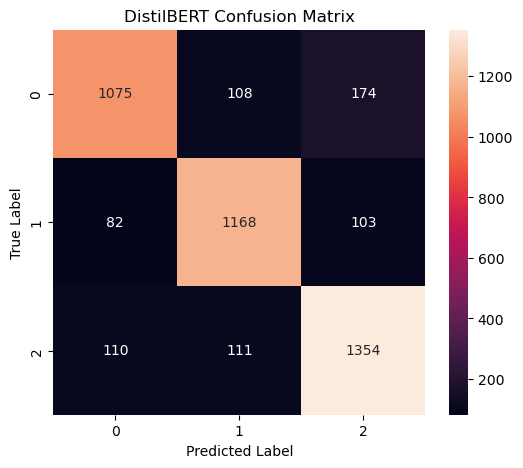

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(
    test_labels,
    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("DistilBERT Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [ ]:
# SAVE MODEL

model.save_pretrained(
    "./distilbert_stress_model"
)

tokenizer.save_pretrained(
    "./distilbert_stress_model"
)

print("\nModel Saved Successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model Saved Successfully!


In [19]:
# PREDICTION FUNCTION
def predict_stress(text):
    model.eval() 
    with torch.no_grad():
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=64
        )
        
        inputs = {key: val.to(device) for key, val in inputs.items()}

        outputs = model(**inputs)
        prediction = torch.argmax(
            outputs.logits,
            dim=1
        ).item()

    return prediction
